In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("../data/raw/housing.csv")

In [3]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200


In [4]:
df.shape

(20640, 9)

In [5]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  int64  
dtypes: float64(4), int64(5)
memory usage: 1.4 MB


After basic info, we go ahead to see the missing values, duplicates, outliers, distributions of features, corrrelation.

In [7]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
dtype: int64

In [8]:
(df['total_bedrooms'].isnull().sum()/df.shape[0])*100 #1%

np.float64(1.002906976744186)

Now we try to plot some graphs like histogram and boxplot(outliers)

Text(0, 0.5, 'Frequency')

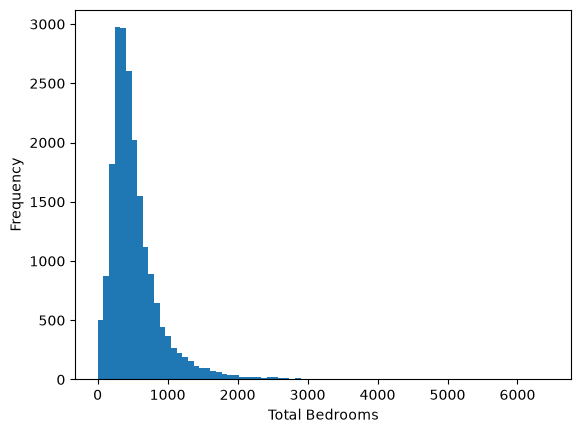

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.hist(df['total_bedrooms'],bins=80)
plt.xlabel("Total Bedrooms")
plt.ylabel("Frequency")


As we see above, there is slight skewness right. So we can choose median to impute missing values. alternatively, we can also drop them since they are just 1%. Now we also try to support it by seeing if they are randomly distributed.

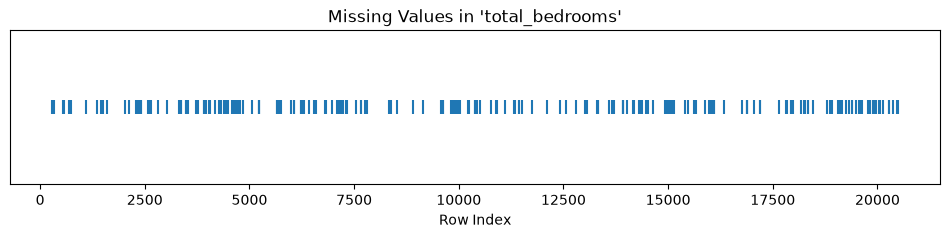

In [10]:
col = "total_bedrooms"

missing = df[df[col].isna()]

plt.figure(figsize=(12, 2))
plt.scatter(missing.index, [1] * len(missing), marker='|', s=100)
plt.yticks([])
plt.xlabel("Row Index")
plt.title(f"Missing Values in '{col}'")
plt.show()

In [11]:
df=df.dropna()
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,78100
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,77100
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,92300
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,84700


In [12]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64

We now move on to univariate analysis. For numerical, we use histograms, and boxplots.

In [13]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='str')

(array([5.900e+01, 6.300e+01, 2.600e+01, 1.400e+01, 2.500e+01, 4.800e+01,
        3.700e+01, 1.290e+02, 3.090e+02, 1.010e+03, 1.285e+03, 1.299e+03,
        9.680e+02, 3.380e+02, 6.410e+02, 6.300e+02, 3.540e+02, 2.180e+02,
        2.090e+02, 2.470e+02, 1.100e+02, 1.550e+02, 3.760e+02, 3.130e+02,
        1.310e+02, 3.270e+02, 3.670e+02, 1.530e+02, 2.700e+02, 1.738e+03,
        2.478e+03, 1.702e+03, 1.023e+03, 5.420e+02, 3.980e+02, 1.076e+03,
        9.120e+02, 1.230e+02, 4.300e+01, 7.400e+01, 5.400e+01, 1.900e+01,
        1.300e+01, 7.000e+01, 2.600e+01, 1.000e+00, 3.000e+00, 1.000e+00,
        2.300e+01, 3.000e+00]),
 array([-124.35  , -124.1492, -123.9484, -123.7476, -123.5468, -123.346 ,
        -123.1452, -122.9444, -122.7436, -122.5428, -122.342 , -122.1412,
        -121.9404, -121.7396, -121.5388, -121.338 , -121.1372, -120.9364,
        -120.7356, -120.5348, -120.334 , -120.1332, -119.9324, -119.7316,
        -119.5308, -119.33  , -119.1292, -118.9284, -118.7276, -118.5268,
      

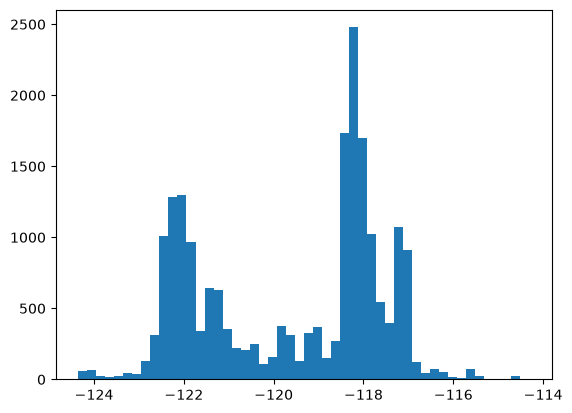

In [14]:
plt.hist(df['longitude'],bins=50)

The longitudes -122 and -118 have more concentration, so the data pts are geographically clustered.
Same for latitudes below.

(array([ 393.,  803.,  225.,  248.,  107.,  432., 1760., 3051., 3049.,
         600.,  247.,  131.,  125.,   73.,  166.,  177.,   62.,   33.,
          75.,  122.,  162.,  240.,  451.,  250.,  175.,  986.,  624.,
        1554., 1052.,  448.,  333.,  496.,  582.,  143.,  174.,  191.,
         102.,   52.,  111.,   31.,   43.,   40.,  113.,   79.,   44.,
          14.,   15.,   12.,   18.,   19.]),
 array([32.54  , 32.7282, 32.9164, 33.1046, 33.2928, 33.481 , 33.6692,
        33.8574, 34.0456, 34.2338, 34.422 , 34.6102, 34.7984, 34.9866,
        35.1748, 35.363 , 35.5512, 35.7394, 35.9276, 36.1158, 36.304 ,
        36.4922, 36.6804, 36.8686, 37.0568, 37.245 , 37.4332, 37.6214,
        37.8096, 37.9978, 38.186 , 38.3742, 38.5624, 38.7506, 38.9388,
        39.127 , 39.3152, 39.5034, 39.6916, 39.8798, 40.068 , 40.2562,
        40.4444, 40.6326, 40.8208, 41.009 , 41.1972, 41.3854, 41.5736,
        41.7618, 41.95  ]),
 <BarContainer object of 50 artists>)

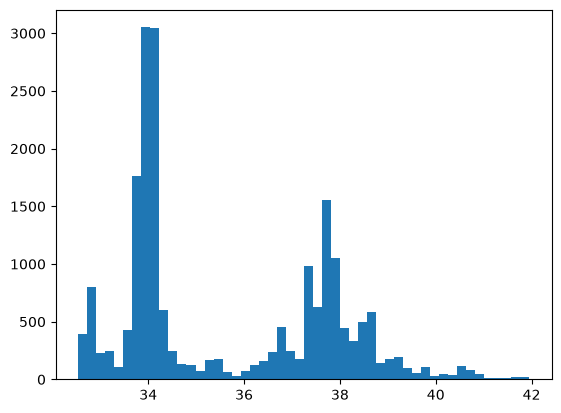

In [15]:
plt.hist(df['latitude'],bins=50)

(array([ 314.,  572.,  922.,  944., 1963., 1965., 1313., 2123., 1372.,
        1851., 2587.,  960., 1353.,  614., 1580.]),
 array([ 1. ,  4.4,  7.8, 11.2, 14.6, 18. , 21.4, 24.8, 28.2, 31.6, 35. ,
        38.4, 41.8, 45.2, 48.6, 52. ]),
 <BarContainer object of 15 artists>)

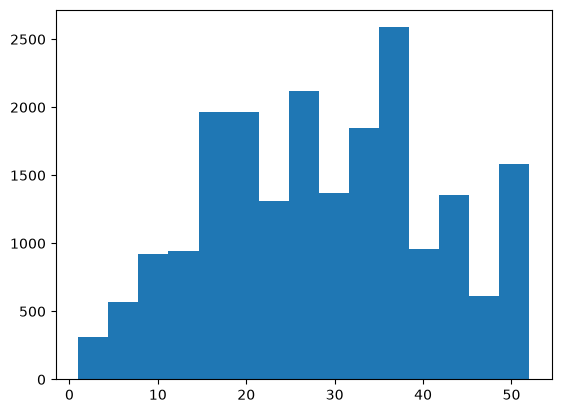

In [16]:
plt.hist(df['housing_median_age'],bins=15)

Here we observe the graph is not normally distributed. It has several peaks, a noticeable spike at 52 to 54 region, suggesting capping done.

(array([1.5432e+04, 4.0970e+03, 6.4000e+02, 1.5900e+02, 5.9000e+01,
        2.2000e+01, 1.3000e+01, 6.0000e+00, 4.0000e+00, 1.0000e+00]),
 array([1.0000e+00, 6.0910e+02, 1.2172e+03, 1.8253e+03, 2.4334e+03,
        3.0415e+03, 3.6496e+03, 4.2577e+03, 4.8658e+03, 5.4739e+03,
        6.0820e+03]),
 <BarContainer object of 10 artists>)

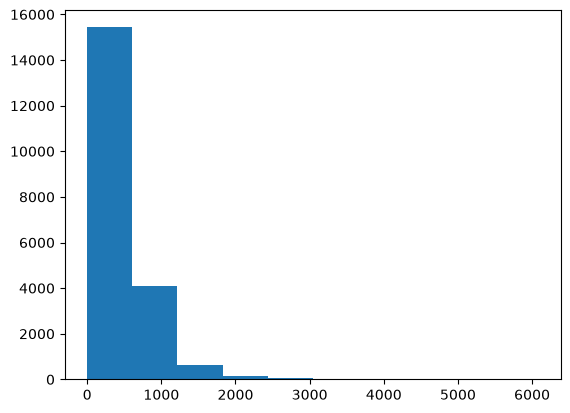

In [17]:
plt.hist(df['households'])

Right Skewed. concentration at 0 to 1000.

(array([2221., 7360., 6039., 2962., 1052.,  423.,  175.,   92.,   47.,
          62.]),
 array([ 0.4999 ,  1.94992,  3.39994,  4.84996,  6.29998,  7.75   ,
         9.20002, 10.65004, 12.10006, 13.55008, 15.0001 ]),
 <BarContainer object of 10 artists>)

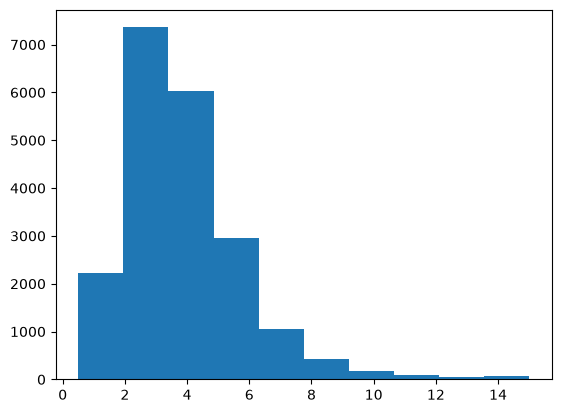

In [18]:
plt.hist(df['median_income'])

Right shifted, peak at 2 to 4

<Axes: ylabel='longitude'>

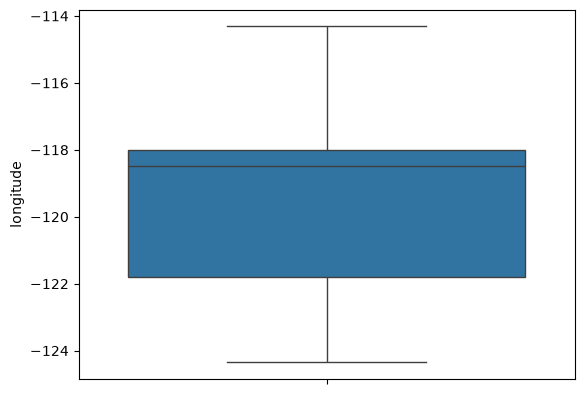

In [19]:
sns.boxplot(df['longitude'])

<Axes: ylabel='latitude'>

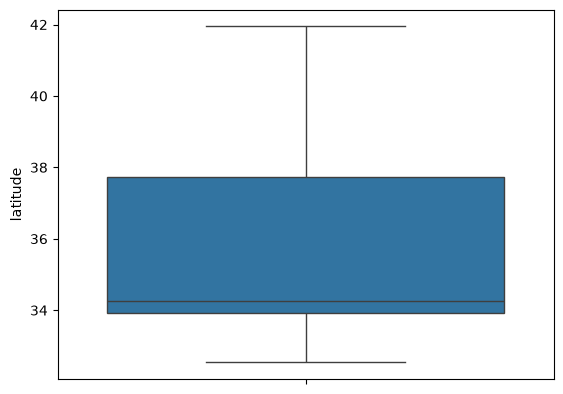

In [20]:
sns.boxplot(df['latitude'])

<Axes: ylabel='households'>

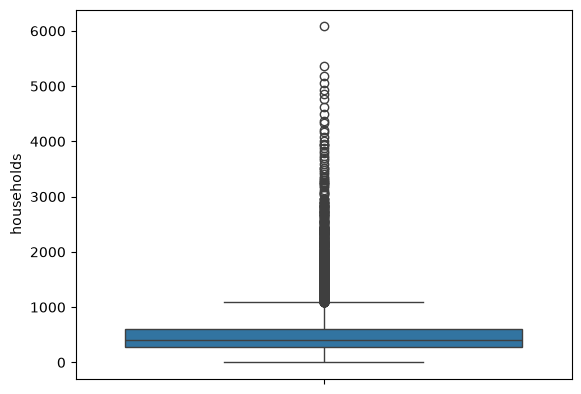

In [21]:
sns.boxplot(df['households'])

Has outliers on the max edge.

<Axes: ylabel='housing_median_age'>

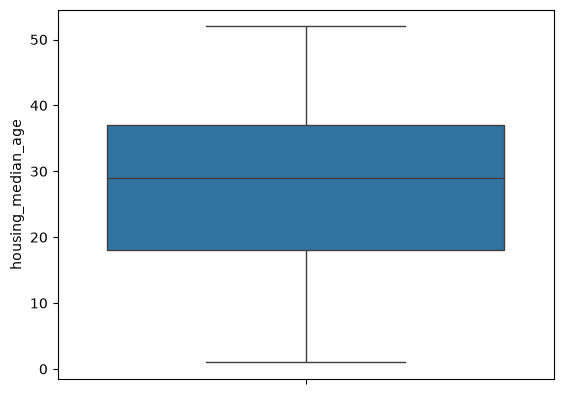

In [22]:
sns.boxplot(df['housing_median_age'])

<Axes: ylabel='median_income'>

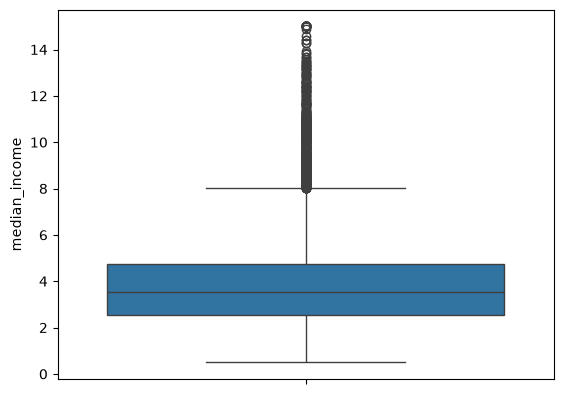

In [23]:
sns.boxplot(df['median_income'])

<Axes: ylabel='population'>

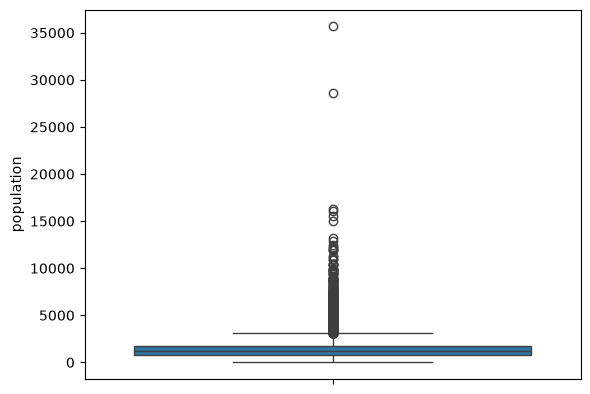

In [24]:
sns.boxplot(df['population'])

<Axes: ylabel='total_bedrooms'>

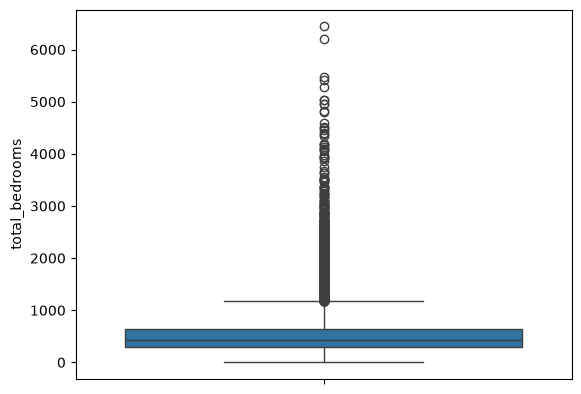

In [25]:
sns.boxplot(df['total_bedrooms'])

<Axes: ylabel='total_rooms'>

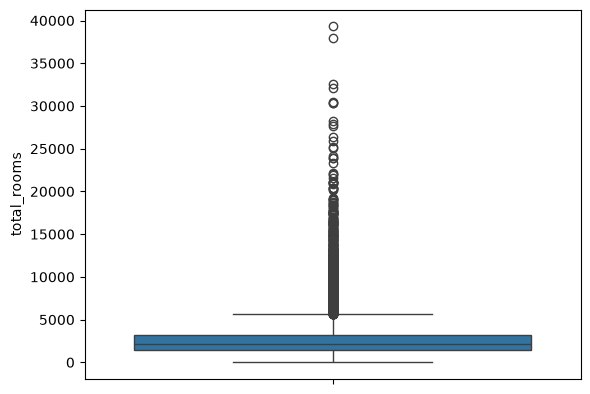

In [26]:
sns.boxplot(df['total_rooms'])

Here, population having outliers is absolutely fine. Similarly for others we can cap at a certain value, coz their outlier density is itself huge. We will be using a linear model, so first we will let it be and trian model then come back to change if needed.

In [27]:
df.duplicated().sum()

np.int64(0)

In [28]:
df.corr()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924616,-0.109357,0.045480,0.069608,0.100270,0.056513,-0.015550,-0.045398
latitude,-0.924616,1.000000,0.011899,-0.036667,-0.066983,-0.108997,-0.071774,-0.079626,-0.144638
housing_median_age,-0.109357,0.011899,1.000000,-0.360628,-0.320451,-0.295787,-0.302768,-0.118278,0.106432
total_rooms,0.045480,-0.036667,-0.360628,1.000000,0.930380,0.857281,0.918992,0.197882,0.133294
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.100270,-0.108997,-0.295787,0.857281,0.877747,1.000000,0.907186,0.005087,-0.025300
households,0.056513,-0.071774,-0.302768,0.918992,0.979728,0.907186,1.000000,0.013434,0.064894
median_income,-0.015550,-0.079626,-0.118278,0.197882,-0.007723,0.005087,0.013434,1.000000,0.688355
median_house_value,-0.045398,-0.144638,0.106432,0.133294,0.049686,-0.025300,0.064894,0.688355,1.000000


<Axes: >

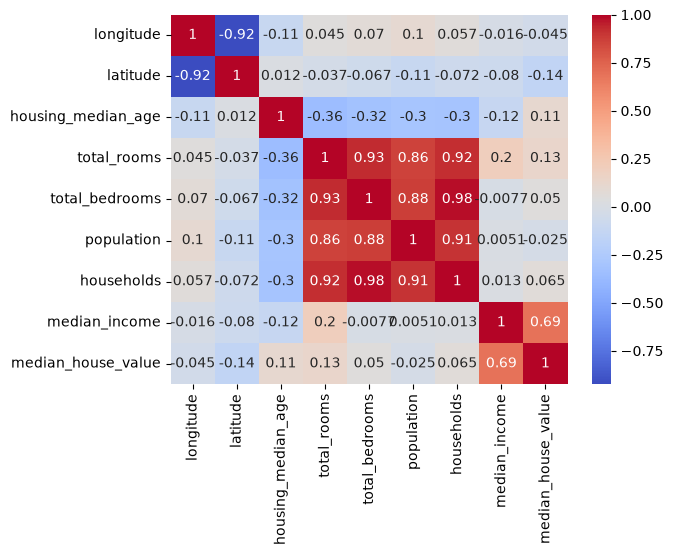

In [29]:
sns.heatmap(df.corr(),annot=True, cmap="coolwarm")

We feel no need to remove any features, we may engineer as total_bedrooms per house but later.

In [30]:
from sklearn.model_selection import train_test_split
X=df.drop(columns="median_house_value")
Y=df["median_house_value"]

In [31]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=2)

In [32]:
print(X_train.shape,Y_train.shape,X_test.shape,Y_test.shape)

(16346, 8) (16346,) (4087, 8) (4087,)


In [33]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train_new=sc.fit_transform(X_train)
X_test_new=sc.transform(X_test)

In [34]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train_new,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[-84803.51,-90189.05, 14505.01,...,-42649.92, 18999.74, 77531.11]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.073e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](8,)","[252.44,176.74,132.21,..., 36.51, 27.58, 15.93]"


In [35]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
def calculate_metrics(model,X_train_new,X_test_new,Y_train,Y_test):
    prediction_train=model.predict(X_train_new)
    r2_train=r2_score(prediction_train,Y_train)
    mae_train=mean_absolute_error(prediction_train,Y_train)
    mse_train=mean_squared_error(prediction_train,Y_train)
    rmse_train=np.sqrt(mse_train)
    print("Training Data Metrics:\nR2: ",r2_train,"\nMAE: ",mae_train,"\nMSE: ",mse_train,"\nRMSE: ",rmse_train,"\n")
    prediction_test=model.predict(X_test_new)
    r2_test=r2_score(prediction_test,Y_test)
    mae_test=mean_absolute_error(prediction_test,Y_test)
    mse_test=mean_squared_error(prediction_test,Y_test)
    rmse_test=np.sqrt(mse_test)
    print("Test Data Metrics:\nR2: ",r2_test,"\nMAE: ",mae_test,"\nMSE: ",mse_test,"\nRMSE: ",rmse_test)
calculate_metrics(lr,X_train_new,X_test_new,Y_train,Y_test)

Training Data Metrics:
R2:  0.4357544509578385 
MAE:  50830.606781772585 
MSE:  4851302301.39828 
RMSE:  69651.29073748943 

Test Data Metrics:
R2:  0.3930929326929621 
MAE:  50733.07473797575 
MSE:  4792579709.946009 
RMSE:  69228.46025982384


We observe we dont have very great metrics. Since, we have little to hyperparameter tuning, we do feature engineering. Specifically feature construction.

Here we observe each row is a census block. it represents a part of the california. The columns represent:
Median age: age of houses in that block.
Total rooms: in that block combining all households(no. of houses).
So we can decide to split it as no. of rooms per household instead.

In [36]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200


In [37]:
df.insert(3,column="room_per_house",value=(df["total_rooms"]/df["households"]))

In [38]:
df.insert(5,column="beds_per_room",value=(df["total_bedrooms"]/df["total_rooms"]))
df.insert(7,column="bedroom_per_house",value=(df["total_bedrooms"]/df["households"]))


In [40]:
df.head()

,longitude,latitude,housing_median_age,room_per_house,total_rooms,beds_per_room,total_bedrooms,bedroom_per_house,population,households,median_income,median_house_value
0,-122.23,37.88,41,6.984127,880,0.146591,129.0,1.023810,322,126,8.3252,452600
1,-122.22,37.86,21,6.238137,7099,0.155797,1106.0,0.971880,2401,1138,8.3014,358500
2,-122.24,37.85,52,8.288136,1467,0.129516,190.0,1.073446,496,177,7.2574,352100
3,-122.25,37.85,52,5.817352,1274,0.184458,235.0,1.073059,558,219,5.6431,341300
4,-122.25,37.85,52,6.281853,1627,0.172096,280.0,1.081081,565,259,3.8462,342200


In [40]:
df.to_csv("../data/processed/housing_clean.csv",index=False)

Now we will retrain our model.

In [41]:
X=df.drop(columns="median_house_value")
Y=df["median_house_value"]
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=2)

In [42]:
sc=StandardScaler()
X_train_new=sc.fit_transform(X_train)
X_test_new=sc.transform(X_test)

In [43]:
lr=LinearRegression()
lr.fit(X_train_new,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](11,)","[-83669. ,-88437.61, 14567.04,...,-45099.03, 38653.06, 79375.24]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.073e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,11
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(11)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](11,)","[252.48,190.75,175.05,..., 26.26, 18.82, 13.85]"


In [44]:
calculate_metrics(lr,X_train_new=X_train_new,X_test_new=X_test_new,Y_test=Y_test,Y_train=Y_train)

Training Data Metrics:
R2:  0.4601745551938181 
MAE:  49789.929614981476 
MSE:  4714948824.207695 
RMSE:  68665.48495574539 

Test Data Metrics:
R2:  0.4158000474393233 
MAE:  49690.80182086649 
MSE:  4652907898.961583 
RMSE:  68212.226902232


We observe slight improvement is metrics. ALthough not huge, our engineered features have helped us a bit.
Perhaps it is because the data is not very linear. Let us try a non linear model like random forest and decision trees.

In [45]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

svr=SVR()
rf=RandomForestRegressor()
dt=DecisionTreeRegressor()

svr.fit(X_train_new,Y_train)
rf.fit(X_train_new,Y_train)
dt.fit(X_train_new,Y_train)

,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_node

In [46]:
calculate_metrics(svr,X_train_new,X_test_new,Y_train,Y_test)

Training Data Metrics:
R2:  -53418.2349489153 
MAE:  88495.99601354609 
MSE:  14107871547.296314 
RMSE:  118776.56143910007 

Test Data Metrics:
R2:  -50707.11278769731 
MAE:  86438.08299680053 
MSE:  13383962551.770082 
RMSE:  115689.0770633515


In [47]:
calculate_metrics(rf,X_train_new,X_test_new,Y_train,Y_test)

Training Data Metrics:
R2:  0.968263011204129 
MAE:  12561.919111097515 
MSE:  368219635.97176427 
RMSE:  19189.04989757868 

Test Data Metrics:
R2:  0.7258776552492976 
MAE:  34205.488495228776 
MSE:  2635252022.1616116 
RMSE:  51334.705825217425


In [48]:
calculate_metrics(dt,X_train_new,X_test_new,Y_train,Y_test)

Training Data Metrics:
R2:  1.0 
MAE:  0.0 
MSE:  0.0 
RMSE:  0.0 

Test Data Metrics:
R2:  0.6063224356421892 
MAE:  46259.6195253242 
MSE:  5082831332.949596 
RMSE:  71293.97823764358


In [49]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
dt=DecisionTreeRegressor()
parameters={
    "max_depth":[1,2,3,5,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf": [2,5,10],
}
grid=GridSearchCV(estimator=dt,param_grid=parameters,cv=5,scoring="r2")
grid.fit(X_train_new,Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [1, 2, ...], 'min_samples_leaf': [2, 5, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls t

In [50]:
grid.best_params_

{'max_depth': None, 'min_samples_leaf': 10, 'min_samples_split': 10}

In [51]:
grid.best_score_

np.float64(0.6990914019965248)

In [52]:
grid.best_estimator_

,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_no

In [53]:
dt=DecisionTreeRegressor(min_samples_leaf=10,min_samples_split=10)
dt.fit(X_train_new,Y_train)

,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_no

In [54]:
calculate_metrics(dt,X_train_new,X_test_new,Y_train,Y_test)

Training Data Metrics:
R2:  0.829473317200381 
MAE:  29106.495666976003 
MSE:  1959323510.2015488 
RMSE:  44264.24640950695 

Test Data Metrics:
R2:  0.6534142351575833 
MAE:  41153.40590711879 
MSE:  3821640247.223515 
RMSE:  61819.41642577609


In [55]:
rf=RandomForestRegressor()
params={
    "n_estimators": [50,100,150,500,1000],
    "max_depth":[None, 2, 5,10],
    "min_samples_split":[2,3,5,10],
    "min_samples_leaf":[2,3,5,10],
    "max_features":[1,2,5,10],
    "bootstrap":[True,False]
}
grid2=RandomizedSearchCV(rf,params,scoring="r2",cv=5,n_jobs=-1,random_state=42)
grid2.fit(X_train_new,Y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'bootstrap': [True, False], 'max_depth': [None, 2, ...], 'max_features': [1, 2, ...], 'min_samples_leaf': [2, 3, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric e

In [56]:
grid2.best_params_

{'n_estimators': 150,
 'min_samples_split': 2,
 'min_samples_leaf': 5,
 'max_features': 5,
 'max_depth': None,
 'bootstrap': False}

In [57]:
grid2.best_score_

np.float64(0.8053886093482466)

In [44]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
rf=RandomForestRegressor()
params={
    "n_estimators": [140,150,160],
    "max_depth":[None,1],
    "min_samples_split":[0,1,2,3],
    "min_samples_leaf":[4,5,6],
    "max_features":[4,5,6],
    "bootstrap":[True,False]
}
grid2=GridSearchCV(rf,params,scoring="r2",cv=3,n_jobs=-1)
grid2.fit(X_train_new,Y_train)

c:\Users\Amina Fatima\My Projects\ML\Regression\venv\Lib\site-packages\sklearn\model_selection\_validation.py:489: FitFailedWarning: 
648 fits failed out of a total of 1296.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
324 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Amina Fatima\My Projects\ML\Regression\venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Amina Fatima\My Projects\ML\Regression\venv\Lib\site-packages\sklearn\base.py", line 1393, in wrapper
    estimator._validate_params()
  File "c:\Users\Amina Fatima\My Projects\ML\Regression\venv\Lib\site-packages\sklearn\base.py", l

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'bootstrap': [True, False], 'max_depth': [None, 1], 'max_features': [4, 5, ...], 'min_samples_leaf': [4, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: 

In [45]:
grid2.best_params_

{'bootstrap': False,
 'max_depth': None,
 'max_features': 5,
 'min_samples_leaf': 4,
 'min_samples_split': 2,
 'n_estimators': 150}

In [46]:
rf=RandomForestRegressor(n_estimators=150,min_samples_leaf=4,max_features=5,bootstrap=False)
rf.fit(X_train_new,Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",5
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",False
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the

In [47]:
calculate_metrics(rf,X_train_new,X_test_new,Y_train,Y_test)

Training Data Metrics:
R2:  0.9558680643104279 
MAE:  13444.2999072051 
MSE:  517293815.5737339 
RMSE:  22744.094081183666 

Test Data Metrics:
R2:  0.7651019717497981 
MAE:  31735.424303272863 
MSE:  2391009042.587852 
RMSE:  48897.94517756193


In [48]:
comparison={
    "Model":["LinearRegression","LinearRegression+FE","DecisionTree","DecisionTree Tuned","RandomForest","RandomForest Tuned"],
    "Train_R2":[0.43,0.46,1,0.829,0.968,0.955],
    "Test_R2":[0.39,0.415,0.60,0.653,0.725,0.765],
    "MAE_Train":[50830,49789,0,29106,12561,13444],
    "MAE_Test":[50733,49690,46259,41153,34205,31735],
    "RMSE_Train":[69651,68665,0,44264,19189,22744],
    "RMSE_Test":[69228,68212,71293,61819,51334,48897]
}
print(pd.DataFrame(comparison))

                 Model  Train_R2  Test_R2  MAE_Train  MAE_Test  RMSE_Train  \
0     LinearRegression     0.430    0.390      50830     50733       69651   
1  LinearRegression+FE     0.460    0.415      49789     49690       68665   
2         DecisionTree     1.000    0.600          0     46259           0   
3   DecisionTree Tuned     0.829    0.653      29106     41153       44264   
4         RandomForest     0.968    0.725      12561     34205       19189   
5   RandomForest Tuned     0.955    0.765      13444     31735       22744   

   RMSE_Test  
0      69228  
1      68212  
2      71293  
3      61819  
4      51334  
5      48897  


Linear Regression is baseline model, with no overfitting. Feature Engineeering gave a little more improvemnt. Decision Tree has high overfitting, Tuning helped a little. Random Forest has really good performance. with little overfitting. Tuning reduces overfitting, generalizing it.Complexity reduced. 

In [63]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'room_per_house',
       'total_rooms', 'beds_per_room', 'total_bedrooms', 'bedroom_per_house',
       'population', 'households', 'median_income', 'median_house_value'],
      dtype='str')

In [65]:
rf.feature_importances_

array([0.13647672, 0.13322164, 0.04940286, 0.0457717 , 0.01427821,
       0.1061203 , 0.01608488, 0.0184148 , 0.0228785 , 0.01425127,
       0.44309913])

In [66]:
feature_importance={
    "Column Name":['longitude', 'latitude', 'housing_median_age', 'room_per_house',
       'total_rooms', 'beds_per_room', 'total_bedrooms', 'bedroom_per_house',
       'population', 'households', 'median_income'],
    "Importance": rf.feature_importances_
}
print(pd.DataFrame(feature_importance))

           Column Name  Importance
0            longitude    0.136477
1             latitude    0.133222
2   housing_median_age    0.049403
3       room_per_house    0.045772
4          total_rooms    0.014278
5        beds_per_room    0.106120
6       total_bedrooms    0.016085
7    bedroom_per_house    0.018415
8           population    0.022879
9           households    0.014251
10       median_income    0.443099


We observe median_income, longitude, latitude are more important features.

In [2]:
import pandas as pd
df=pd.read_csv("../data/processed/housing_clean.csv")
df.sample(1)

,longitude,latitude,housing_median_age,room_per_house,total_rooms,beds_per_room,total_bedrooms,bedroom_per_house,population,households,median_income,median_house_value
15180,-117.29,33.24,5,5.378893,3109,0.203924,634.0,1.096886,1823,578,3.1875,153800


In [3]:
target = {
    "longitude": -122.23,
    "latitude": 37.88,
    "housing_median_age": 30,
    "total_rooms": 2500,
    "total_bedrooms": 500,
    "population": 1200,
    "households": 450,
    "median_income": 3.5
}

cols = list(target.keys())

closest = (
    (df[cols] - pd.Series(target))
    .pow(2)
    .sum(axis=1)
    .idxmin()
)

print(df.loc[closest])

longitude               -123.800000
latitude                  39.470000
housing_median_age        28.000000
room_per_house             5.417391
total_rooms             2492.000000
beds_per_room              0.203451
total_bedrooms           507.000000
bedroom_per_house          1.102174
population              1202.000000
households               460.000000
median_income              2.785700
median_house_value    150300.000000
Name: 9370, dtype: float64
